# New SINR And PRB Check

This notebook checks the corrected radio path after the per-PRB power and load-aware interference fix. It shows:

- SNR/SINR across the center-left-right topology.
- What happens when a same-carrier neighbor is idle vs active.
- Per-UE PRB allocation in the upper-agent training scenarios.

In [13]:
import os, sys
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-chech')
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scenario_creator import create_multignb_env
from global_ppo_3gnb_env import GlobalPPO3GNBEnv
from upper_agent_training_scenarios import CENTER_GAP_GNB_CONFIGS

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})
GNB_CONFIGS = CENTER_GAP_GNB_CONFIGS['medium_270m']
GNB_CONFIGS

({'id': 0,
  'x': -270.0,
  'y': 0.0,
  'coverage_radius': 500.0,
  'carrier_id': 0,
  'center_frequency_hz': 3500000000.0,
  'bandwidth_hz': 20000000.0,
  'tx_power_dbm': 30.0,
  'noise_figure_db': 7.0},
 {'id': 1,
  'x': 0.0,
  'y': 0.0,
  'coverage_radius': 500.0,
  'carrier_id': 0,
  'center_frequency_hz': 3500000000.0,
  'bandwidth_hz': 20000000.0,
  'tx_power_dbm': 30.0,
  'noise_figure_db': 7.0},
 {'id': 2,
  'x': 270.0,
  'y': 0.0,
  'coverage_radius': 500.0,
  'carrier_id': 0,
  'center_frequency_hz': 3500000000.0,
  'bandwidth_hz': 20000000.0,
  'tx_power_dbm': 30.0,
  'noise_figure_db': 7.0})

## 1. Position Sweep With Idle Neighbors

All gNBs still share the same carrier, but idle gNBs no longer create full-power interference. The UE is forced to be served by center gNB1 so we can inspect the exact old suspicious positions around x = +/-135 m.

In [14]:
def force_serving(env, ue_id, gnb_id):
    ue = env.get_ue(ue_id)
    for gnb in env.gnbs:
        gnb.detach_ue(ue_id)
    target = env._get_gnb_by_id(gnb_id)
    target.attach_ue(ue)
    ue.serving_gnb = gnb_id
    ue.connected = True
    env._invalidate_metric_caches()


def make_base_env(seed=1, traffic_bps=0.0):
    rng = np.random.default_rng(seed)
    return create_multignb_env(
        rng,
        n=0,
        L1_level=False,
        gnb_configs=GNB_CONFIGS,
        step_dt=1e-3,
        mobility_dt=1e-3,
        radio_substeps=1,
        max_episode_steps=8,
        ue_traffic_profiles={
            'eMBB': {
                'traffic_model': 'fixed_packet_cbr',
                'packet_size_bits': 12000.0,
                'bit_rate': float(traffic_bps),
            }
        },
    )


positions = [-165, -135, -100, -50, 0, 50, 100, 135, 165]
env = make_base_env(seed=1, traffic_bps=0.0)
rows = []
try:
    for x in positions:
        ue_id = env.add_ue(x=float(x), y=0.0, vx=0.0, vy=0.0, slice_type='eMBB')
        force_serving(env, ue_id, 1)
        m = env.get_ue_radio_metrics(ue_id)
        rows.append({
            'x_m': x,
            'serving_gnb': m['serving_gnb'],
            'rx_power_per_prb_dbm': m['rx_power_dbm'],
            'rx_power_total_dbm': m['rx_power_total_dbm'],
            'rsrp_dbm': m['rsrp_dbm'],
            'noise_dbm': m['noise_dbm'],
            'interference_dbm': m['interference_dbm'],
            'snr_db': m['snr_db'],
            'sinr_db': m['sinr_db'],
            'allocated_prbs': m['allocated_prbs'],
            'useful_prbs': m['useful_prbs'],
        })
finally:
    env.close()

sweep = pd.DataFrame(rows)
sweep.round(2)

,x_m,serving_gnb,rx_power_per_prb_dbm,rx_power_total_dbm,rsrp_dbm,noise_dbm,interference_dbm,snr_db,sinr_db,allocated_prbs,useful_prbs
0,-165,1,-96.55,-73.54,-73.54,-114.45,-100.0,17.90,17.90,0,0
1,-135,1,-93.27,-70.26,-70.26,-114.45,-100.0,21.18,21.18,0,0
2,-100,1,-88.37,-65.36,-65.36,-114.45,-100.0,26.08,26.08,0,0
3,-50,1,-77.05,-54.04,-54.04,-114.45,-100.0,37.39,37.39,0,0
4,0,1,-63.01,-40.00,-40.00,-114.45,-100.0,40.00,40.00,0,0
5,50,1,-77.05,-54.04,-54.04,-114.45,-100.0,37.39,37.39,0,0
6,100,1,-88.37,-65.36,-65.36,-114.45,-100.0,26.08,26.08,0,0
7,135,1,-93.27,-70.26,-70.26,-114.45,-100.0,21.18,21.18,0,0
8,165,1,-96.55,-73.54,-73.54,-114.45,-100.0,17.90,17.90,0,0


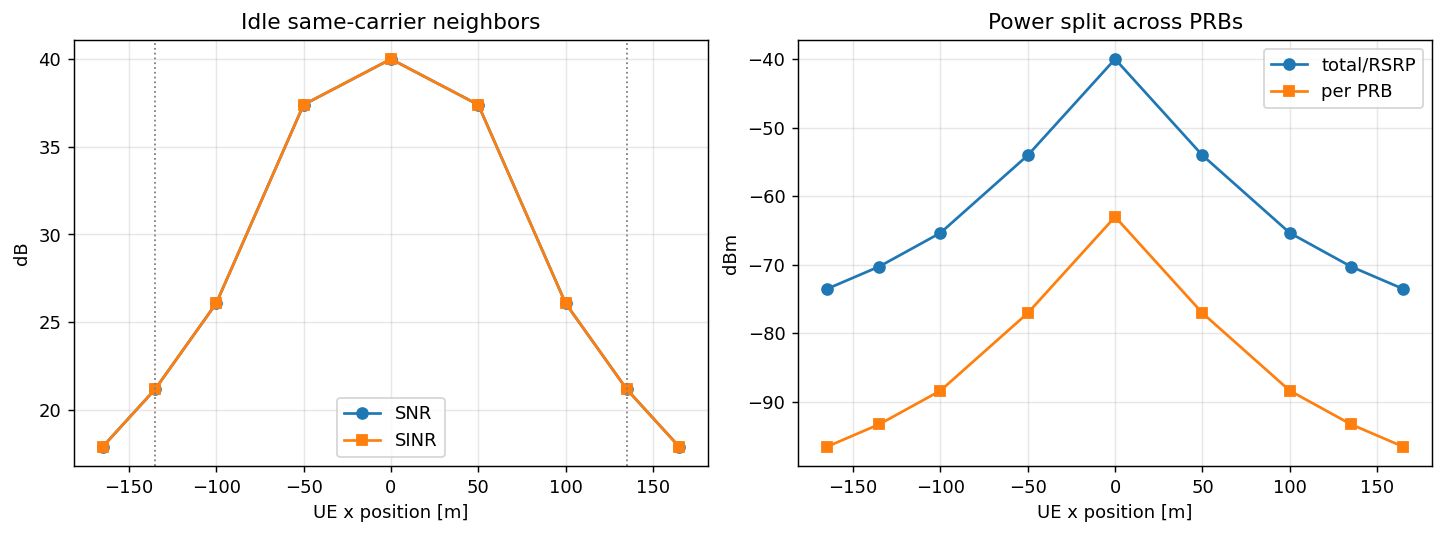

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(sweep['x_m'], sweep['snr_db'], marker='o', label='SNR')
axes[0].plot(sweep['x_m'], sweep['sinr_db'], marker='s', label='SINR')
axes[0].axvline(-135, color='gray', linestyle=':', linewidth=1)
axes[0].axvline(135, color='gray', linestyle=':', linewidth=1)
axes[0].set_xlabel('UE x position [m]')
axes[0].set_ylabel('dB')
axes[0].set_title('Idle same-carrier neighbors')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(sweep['x_m'], sweep['rx_power_total_dbm'], marker='o', label='total/RSRP')
axes[1].plot(sweep['x_m'], sweep['rx_power_per_prb_dbm'], marker='s', label='per PRB')
axes[1].set_xlabel('UE x position [m]')
axes[1].set_ylabel('dBm')
axes[1].set_title('Power split across PRBs')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.show()

## 2. Active Neighbor Interference

This puts one active UE on gNB2 and one probe UE at x = 135 m served by gNB1. The probe sees high SINR when gNB2 is idle and lower SINR only when gNB2 used PRBs in the previous radio tick.

In [16]:
env = make_base_env(seed=2, traffic_bps=5_000_000.0)
trace_rows = []
try:
    active_id = env.add_ue(x=270.0, y=0.0, vx=0.0, vy=0.0, slice_type='eMBB')
    probe_id = env.add_ue(x=135.0, y=0.0, vx=0.0, vy=0.0, slice_type='eMBB')
    force_serving(env, active_id, 2)
    force_serving(env, probe_id, 1)

    for step in range(12):
        env.step(0)
        probe = env.get_ue_radio_metrics(probe_id)
        active = env.get_ue_radio_metrics(active_id)
        trace_rows.append({
            'step': step,
            'g0_activity': env._last_gnb_prb_activity.get(0, 0.0),
            'g1_activity': env._last_gnb_prb_activity.get(1, 0.0),
            'g2_activity': env._last_gnb_prb_activity.get(2, 0.0),
            'probe_snr_db': probe['snr_db'],
            'probe_sinr_db': probe['sinr_db'],
            'probe_interference_dbm': probe['interference_dbm'],
            'probe_allocated_prbs': probe['allocated_prbs'],
            'probe_useful_prbs': probe['useful_prbs'],
            'active_allocated_prbs': active['allocated_prbs'],
            'active_useful_prbs': active['useful_prbs'],
        })
finally:
    env.close()

active_trace = pd.DataFrame(trace_rows)
active_trace.round(3)

,step,g0_activity,g1_activity,g2_activity,probe_snr_db,probe_sinr_db,probe_interference_dbm,probe_allocated_prbs,probe_useful_prbs,active_allocated_prbs,active_useful_prbs
0,0,0.0,0.00,0.00,21.176,21.176,-100.000,0,0,0,0
1,1,0.0,0.00,0.00,21.176,21.176,-100.000,0,0,0,0
2,2,0.0,0.08,0.08,21.176,10.574,-104.241,16,15,16,15
3,3,0.0,0.00,0.00,21.176,21.176,-100.000,0,0,0,0
4,4,0.0,0.08,0.08,21.176,10.574,-104.241,16,15,16,15
5,5,0.0,0.00,0.00,21.176,21.176,-100.000,0,0,0,0
6,6,0.0,0.00,0.00,21.176,21.176,-100.000,0,0,0,0
7,7,0.0,0.08,0.08,21.176,10.574,-104.241,16,15,16,15
8,8,0.0,0.00,0.00,21.176,21.176,-100.000,0,0,0,0
9,9,0.0,0.08,0.08,21.176,10.574,-104.241,16,15,16,15


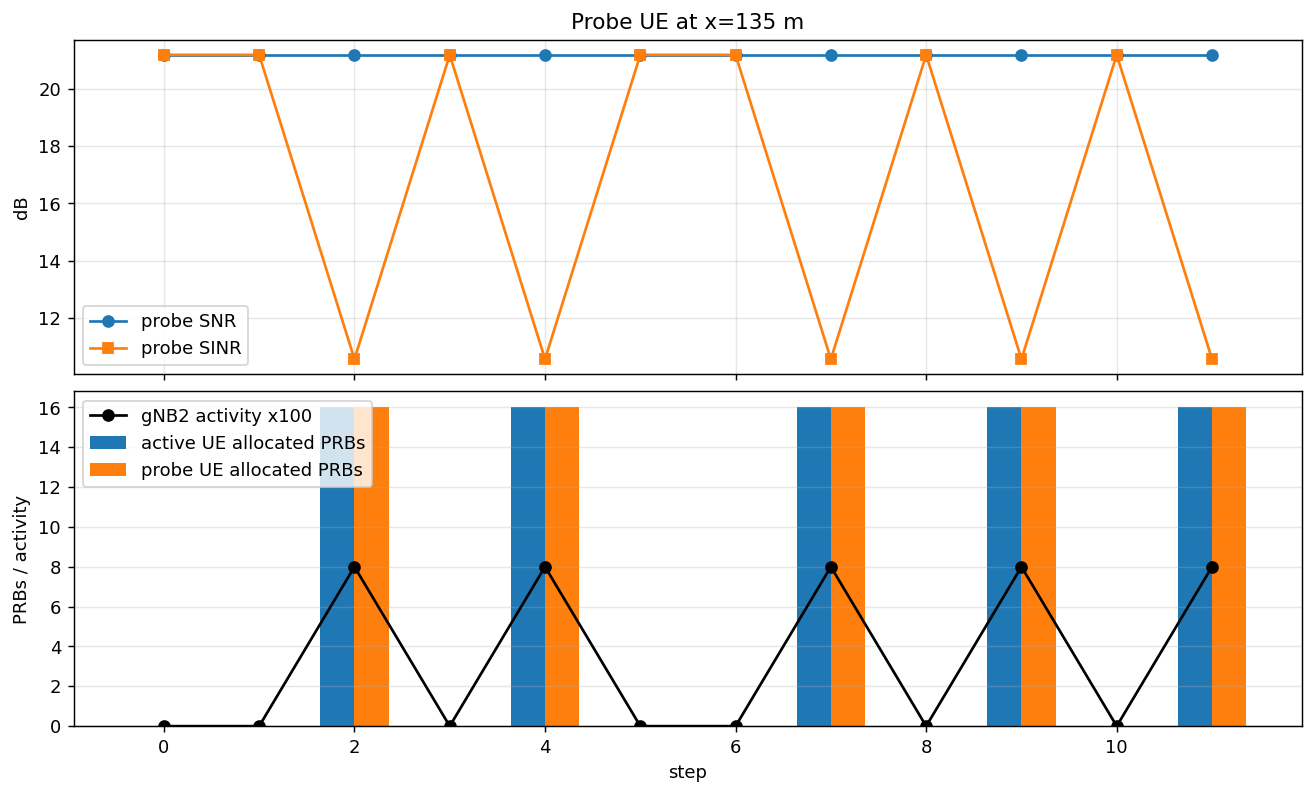

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, constrained_layout=True)
axes[0].plot(active_trace['step'], active_trace['probe_snr_db'], marker='o', label='probe SNR')
axes[0].plot(active_trace['step'], active_trace['probe_sinr_db'], marker='s', label='probe SINR')
axes[0].set_ylabel('dB')
axes[0].set_title('Probe UE at x=135 m')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].bar(active_trace['step'] - 0.18, active_trace['active_allocated_prbs'], width=0.36, label='active UE allocated PRBs')
axes[1].bar(active_trace['step'] + 0.18, active_trace['probe_allocated_prbs'], width=0.36, label='probe UE allocated PRBs')
axes[1].plot(active_trace['step'], active_trace['g2_activity'] * 100, color='black', marker='o', label='gNB2 activity x100')
axes[1].set_xlabel('step')
axes[1].set_ylabel('PRBs / activity')
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].legend()
plt.show()

## 3. Scenario Snapshot: SINR And PRBs

This opens the upper-agent scenario, runs a few neutral actions, and reports the actual per-UE SINR and PRB allocation from the scheduler.

In [18]:
def scenario_radio_snapshot(name, steps=8):
    env = GlobalPPO3GNBEnv(
        seed=0,
        scenario_mode='curriculum',
        training_scenarios=name,
        gnb_configs=GNB_CONFIGS,
        global_steps_per_episode=12,
        local_steps_per_global=10,
        radio_substeps=1,
        warmup_steps=0,
        safe_admission_enabled=False,
        terminal_reward_only=False,
    )
    rows = []
    try:
        env.reset()
        zero = np.zeros(env.action_space.shape, dtype=np.float32)
        for step in range(steps):
            if step > 0:
                env.step(zero)
            for ue in env.base_env.get_all_ues():
                m = env.base_env.get_ue_radio_metrics(ue.id)
                rows.append({
                    'scenario': name,
                    'step': step,
                    'ue_id': int(ue.id),
                    'slice': getattr(ue, 'slice_type', 'eMBB'),
                    'serving_gnb': m['serving_gnb'],
                    'x_m': m['x'],
                    'y_m': m['y'],
                    'snr_db': m['snr_db'],
                    'sinr_db': m['sinr_db'],
                    'interference_dbm': m['interference_dbm'],
                    'allocated_prbs': m['allocated_prbs'],
                    'useful_prbs': m['useful_prbs'],
                    'wasted_prbs': m['wasted_prbs'],
                    'mcs': m['mcs'],
                    'rx_probability': m['rx_probability'],
                })
    finally:
        env.close()
    return pd.DataFrame(rows)


snapshots = pd.concat([
    scenario_radio_snapshot('jain_balance_controllable', steps=8),
    scenario_radio_snapshot('high_load_inner_embb', steps=8),
], ignore_index=True)

summary = snapshots.groupby(['scenario', 'step']).agg(
    mean_sinr_db=('sinr_db', 'mean'),
    min_sinr_db=('sinr_db', 'min'),
    total_allocated_prbs=('allocated_prbs', 'sum'),
    total_useful_prbs=('useful_prbs', 'sum'),
    active_ues=('allocated_prbs', lambda s: int((s > 0).sum())),
).reset_index()

summary.round(2)

,scenario,step,mean_sinr_db,min_sinr_db,total_allocated_prbs,total_useful_prbs,active_ues
0,high_load_inner_embb,0,24.28,24.14,90,90,6
1,high_load_inner_embb,1,24.28,24.14,96,93,6
2,high_load_inner_embb,2,24.28,24.14,94,92,6
3,high_load_inner_embb,3,24.28,24.14,90,87,6
4,high_load_inner_embb,4,24.28,24.14,90,87,6
5,high_load_inner_embb,5,24.28,24.14,92,89,6
6,high_load_inner_embb,6,24.28,24.14,100,99,6
7,high_load_inner_embb,7,24.28,24.14,100,98,6
8,jain_balance_controllable,0,23.92,23.79,90,90,6
9,jain_balance_controllable,1,23.92,23.79,92,88,6


In [19]:
last_step = snapshots['step'].max()
latest = snapshots[snapshots['step'] == last_step].copy()
latest.sort_values(['scenario', 'serving_gnb', 'ue_id']).round(2)

,scenario,step,ue_id,slice,serving_gnb,x_m,y_m,snr_db,sinr_db,interference_dbm,allocated_prbs,useful_prbs,wasted_prbs,mcs,rx_probability
90,high_load_inner_embb,7,0,eMBB,1,-132.0,-30.0,24.14,24.14,-100.0,18,18,0,15,1.00
91,high_load_inner_embb,7,1,eMBB,1,132.0,-30.0,24.14,24.14,-100.0,18,18,0,24,0.97
92,high_load_inner_embb,7,2,eMBB,1,-132.0,0.0,24.55,24.55,-100.0,14,14,0,25,1.00
93,high_load_inner_embb,7,3,eMBB,1,132.0,0.0,24.55,24.55,-100.0,18,18,0,15,1.00
94,high_load_inner_embb,7,4,eMBB,1,-132.0,30.0,24.14,24.14,-100.0,16,15,1,25,1.00
95,high_load_inner_embb,7,5,eMBB,1,132.0,30.0,24.14,24.14,-100.0,16,15,1,25,1.00
42,jain_balance_controllable,7,0,eMBB,1,-135.0,-30.0,23.79,23.79,-100.0,14,14,0,22,1.00
43,jain_balance_controllable,7,1,eMBB,1,135.0,-30.0,23.79,23.79,-100.0,20,20,0,19,1.00
44,jain_balance_controllable,7,2,eMBB,1,-135.0,0.0,24.19,24.19,-100.0,14,14,0,25,1.00
45,jain_balance_controllable,7,3,eMBB,1,135.0,0.0,24.19,24.19,-100.0,14,14,0,25,1.00


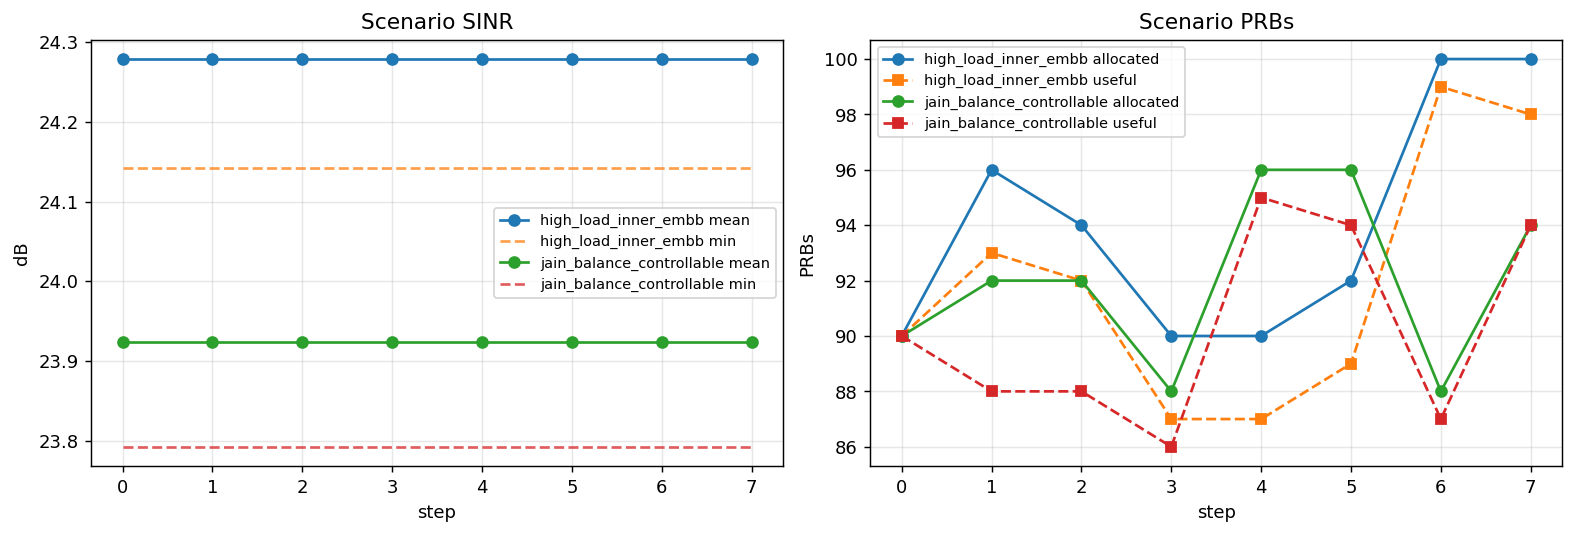

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for scenario, group in summary.groupby('scenario'):
    axes[0].plot(group['step'], group['mean_sinr_db'], marker='o', label=f'{scenario} mean')
    axes[0].plot(group['step'], group['min_sinr_db'], linestyle='--', alpha=0.75, label=f'{scenario} min')
    axes[1].plot(group['step'], group['total_allocated_prbs'], marker='o', label=f'{scenario} allocated')
    axes[1].plot(group['step'], group['total_useful_prbs'], linestyle='--', marker='s', label=f'{scenario} useful')

axes[0].set_title('Scenario SINR')
axes[0].set_xlabel('step')
axes[0].set_ylabel('dB')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].set_title('Scenario PRBs')
axes[1].set_xlabel('step')
axes[1].set_ylabel('PRBs')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)
plt.show()

## 4. Controllable Scenario Plot And Per-UE Calculation

This section separates two PRB quantities that must not be interpreted the same way:

- `demand_prbs`: UE traffic demand carried with the UE. The network total should stay conserved across handover.
- `useful_prbs`: scheduler service realized on each gNB during the radio window. This is not conserved because moving UEs gives their demand access to another gNB PRB pool.

The plots below therefore show demand conservation separately from useful PRB service.


In [21]:
def collect_controllable_scenario(name='jain_balance_controllable', settle_steps=6):
    env = GlobalPPO3GNBEnv(
        seed=0,
        scenario_mode='curriculum',
        training_scenarios=name,
        gnb_configs=GNB_CONFIGS,
        global_steps_per_episode=16,
        local_steps_per_global=10,
        radio_substeps=1,
        warmup_steps=0,
        safe_admission_enabled=False,
        terminal_reward_only=False,
    )
    rows = []
    gnb_rows = []

    def snapshot(tag, control_step):
        for gnb in env.base_env.gnbs:
            gnb_rows.append({
                'tag': tag,
                'control_step': control_step,
                'gnb_id': int(gnb.id),
                'x_m': float(gnb.x),
                'y_m': float(gnb.y),
                'carrier_id': int(getattr(gnb, 'carrier_id', -1)),
                'activity': float(env.base_env._last_gnb_prb_activity.get(int(gnb.id), 0.0)),
            })

        for ue in env.base_env.get_all_ues():
            m = env.base_env.get_ue_radio_metrics(ue.id)
            row = {
                'tag': tag,
                'control_step': control_step,
                'ue_id': int(ue.id),
                'slice': getattr(ue, 'slice_type', 'eMBB'),
                'serving_gnb': int(m['serving_gnb']) if m['serving_gnb'] is not None else -1,
                'x_m': float(m['x']),
                'y_m': float(m['y']),
                'demand_prbs': int(getattr(ue, 'upper_demand_prbs', 0)),
                'snr_db': float(m['snr_db']),
                'sinr_db': float(m['sinr_db']),
                'interference_dbm': float(m['interference_dbm']),
                'allocated_prbs': int(m['allocated_prbs']),
                'useful_prbs': int(m['useful_prbs']),
                'wasted_prbs': int(m['wasted_prbs']),
                'mcs': int(m['mcs']),
                'rx_probability': float(m['rx_probability']) if pd.notna(m['rx_probability']) else np.nan,
            }
            for gnb in env.base_env.gnbs:
                gid = int(gnb.id)
                row[f'distance_g{gid}_m'] = float(gnb.distance_to_ue(ue.x, ue.y))
                link = env.base_env._compute_link_metrics(gnb, ue)
                row[f'rsrp_g{gid}_dbm'] = float(link['rsrp_dbm'])
                row[f'sinr_if_g{gid}_db'] = float(link['sinr_db'])
            rows.append(row)

    try:
        env.reset()
        zero = np.zeros(env.action_space.shape, dtype=np.float32)
        negative = -np.ones(env.action_space.shape, dtype=np.float32)

        snapshot('before', 0)
        _, _, _, _, info = env.step(negative)
        snapshot(f'negative_bias_ho{int(info.get("handover_count", 0))}', 1)
        for step in range(2, settle_steps + 2):
            env.step(zero)
        snapshot('settled', settle_steps + 1)
    finally:
        env.close()

    return pd.DataFrame(rows), pd.DataFrame(gnb_rows)


per_ue, gnb_layout = collect_controllable_scenario('jain_balance_controllable', settle_steps=6)
per_ue.sort_values(['control_step', 'serving_gnb', 'ue_id']).round(2)

,tag,control_step,ue_id,slice,serving_gnb,x_m,y_m,demand_prbs,snr_db,sinr_db,...,rx_probability,distance_g0_m,rsrp_g0_dbm,sinr_if_g0_db,distance_g1_m,rsrp_g1_dbm,sinr_if_g1_db,distance_g2_m,rsrp_g2_dbm,sinr_if_g2_db
0,before,0,0,eMBB,1,-135.0,-30.0,15,23.79,23.79,...,0.00,138.29,-70.65,23.79,138.29,-70.65,23.79,406.11,-88.25,6.20
1,before,0,1,eMBB,1,135.0,-30.0,15,23.79,23.79,...,0.00,406.11,-88.25,6.20,138.29,-70.65,23.79,138.29,-70.65,23.79
2,before,0,2,eMBB,1,-135.0,0.0,15,24.19,24.19,...,0.00,135.00,-70.26,24.19,135.00,-70.26,24.19,405.00,-88.20,6.25
3,before,0,3,eMBB,1,135.0,0.0,15,24.19,24.19,...,0.00,405.00,-88.20,6.25,135.00,-70.26,24.19,135.00,-70.26,24.19
4,before,0,4,eMBB,1,-135.0,30.0,15,23.79,23.79,...,0.00,138.29,-70.65,23.79,138.29,-70.65,23.79,406.11,-88.25,6.20
5,before,0,5,eMBB,1,135.0,30.0,15,23.79,23.79,...,0.00,406.11,-88.25,6.20,138.29,-70.65,23.79,138.29,-70.65,23.79
6,negative_bias_ho6,1,0,eMBB,0,-135.0,-30.0,15,23.79,16.66,...,1.00,138.29,-70.65,16.66,138.29,-70.65,-0.09,406.11,-88.25,-17.61
8,negative_bias_ho6,1,2,eMBB,0,-135.0,0.0,15,24.19,17.01,...,0.98,135.00,-70.26,17.01,135.00,-70.26,-0.09,405.00,-88.20,-17.96
10,negative_bias_ho6,1,4,eMBB,0,-135.0,30.0,15,23.79,16.66,...,0.98,138.29,-70.65,16.66,138.29,-70.65,-0.09,406.11,-88.25,-17.61
7,negative_bias_ho6,1,1,eMBB,2,135.0,-30.0,15,23.79,16.66,...,0.99,406.11,-88.25,-17.61,138.29,-70.65,-0.09,138.29,-70.65,16.66


In [22]:
per_ue_summary = per_ue.groupby(['tag', 'serving_gnb']).agg(
    ue_count=('ue_id', 'nunique'),
    mean_sinr_db=('sinr_db', 'mean'),
    min_sinr_db=('sinr_db', 'min'),
    total_demand_prbs=('demand_prbs', 'sum'),
    total_allocated_prbs=('allocated_prbs', 'sum'),
    total_useful_prbs=('useful_prbs', 'sum'),
).reset_index()

network_prb_summary = per_ue.groupby('tag').agg(
    ue_count=('ue_id', 'nunique'),
    network_demand_prbs=('demand_prbs', 'sum'),
    network_allocated_prbs=('allocated_prbs', 'sum'),
    network_useful_prbs=('useful_prbs', 'sum'),
).reset_index()
network_prb_summary['demand_delta_vs_before'] = (
    network_prb_summary['network_demand_prbs']
    - float(network_prb_summary.loc[network_prb_summary['tag'] == 'before', 'network_demand_prbs'].iloc[0])
)

ue_demand_check = per_ue.pivot_table(
    index=['ue_id', 'slice'],
    columns='tag',
    values='demand_prbs',
    aggfunc='first',
).reset_index()
demand_cols = [c for c in ue_demand_check.columns if c not in ('ue_id', 'slice')]
ue_demand_check['per_ue_demand_conserved'] = (
    ue_demand_check[demand_cols].nunique(axis=1) == 1
)

display(per_ue_summary.round(2))
display(network_prb_summary.round(2))
display(ue_demand_check)


,tag,serving_gnb,ue_count,mean_sinr_db,min_sinr_db,total_demand_prbs,total_allocated_prbs,total_useful_prbs
0,before,1,6,23.92,23.79,90,90,90
1,negative_bias_ho6,0,3,16.78,16.66,45,100,100
2,negative_bias_ho6,2,3,16.78,16.66,45,100,100
3,settled,0,3,19.14,19.02,45,52,49
4,settled,2,3,18.90,18.78,45,48,47


,tag,ue_count,network_demand_prbs,network_allocated_prbs,network_useful_prbs,demand_delta_vs_before
0,before,6,90,90,90,0.0
1,negative_bias_ho6,6,90,200,200,0.0
2,settled,6,90,100,96,0.0


tag,ue_id,slice,before,negative_bias_ho6,settled,per_ue_demand_conserved
0,0,eMBB,15,15,15,True
1,1,eMBB,15,15,15,True
2,2,eMBB,15,15,15,True
3,3,eMBB,15,15,15,True
4,4,eMBB,15,15,15,True
5,5,eMBB,15,15,15,True


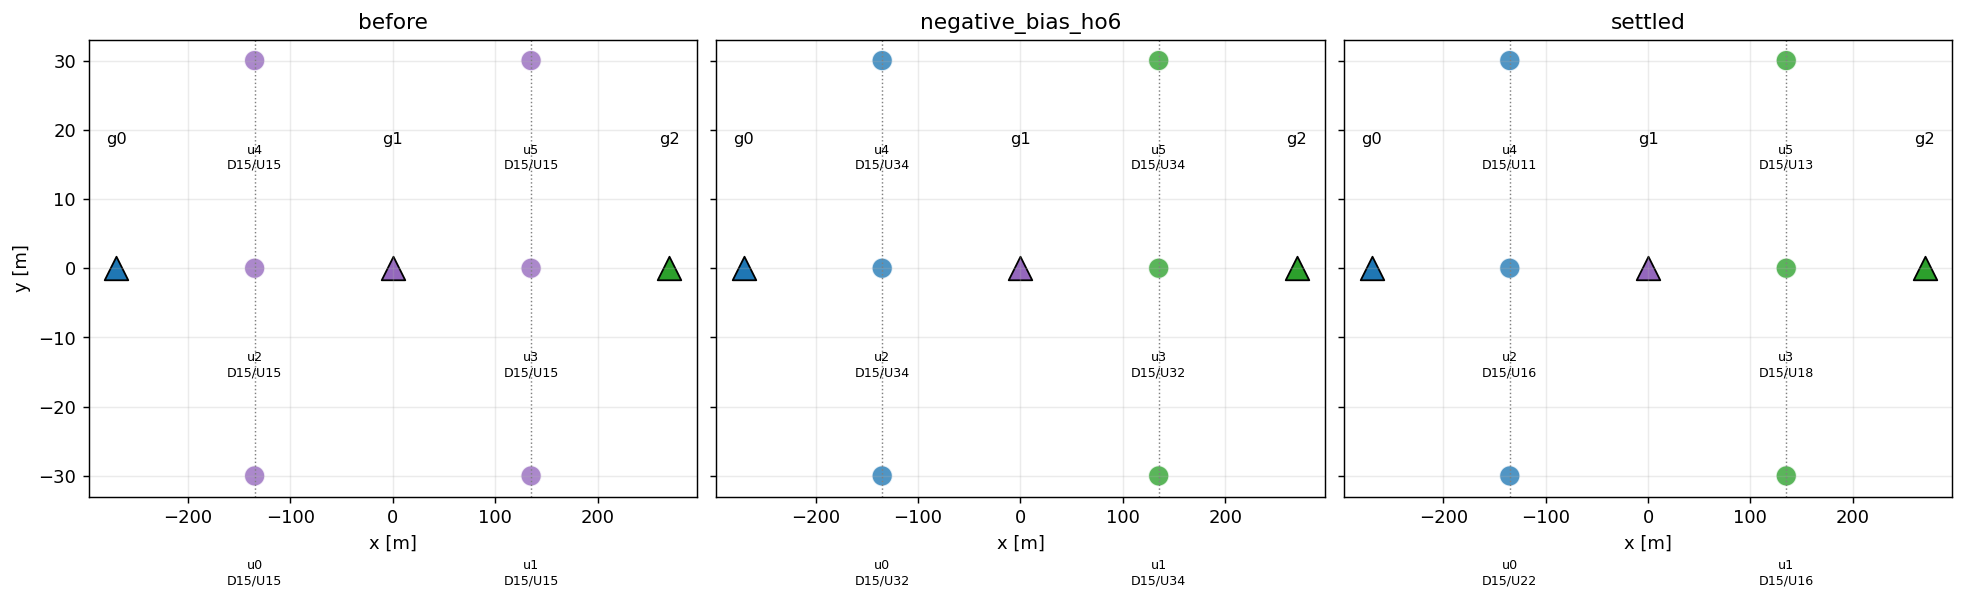

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True, constrained_layout=True)
tags = list(per_ue.sort_values('control_step')['tag'].drop_duplicates())
colors = {0: '#1f77b4', 1: '#9467bd', 2: '#2ca02c'}

for ax, tag in zip(axes, tags):
    gnb_tag = gnb_layout[gnb_layout['tag'] == tag]
    ue_tag = per_ue[per_ue['tag'] == tag]
    for _, gnb in gnb_tag.iterrows():
        ax.scatter(gnb['x_m'], gnb['y_m'], marker='^', s=170, color=colors[int(gnb['gnb_id'])], edgecolor='black')
        ax.text(gnb['x_m'], gnb['y_m'] + 18, f"g{int(gnb['gnb_id'])}", ha='center', fontsize=9)
    for serving, group in ue_tag.groupby('serving_gnb'):
        sizes = 55 + 5 * group['demand_prbs'].clip(lower=0)
        ax.scatter(group['x_m'], group['y_m'], s=sizes, color=colors.get(int(serving), 'gray'), alpha=0.78, edgecolor='white', linewidth=0.8, label=f'g{int(serving)}')
        for _, ue in group.iterrows():
            ax.text(
                ue['x_m'],
                ue['y_m'] - 12,
                f"u{int(ue['ue_id'])}\nD{int(ue['demand_prbs'])}/U{int(ue['useful_prbs'])}",
                ha='center',
                va='top',
                fontsize=7,
            )
    ax.axvline(-135, color='gray', linestyle=':', linewidth=0.8)
    ax.axvline(135, color='gray', linestyle=':', linewidth=0.8)
    ax.set_title(tag)
    ax.set_xlabel('x [m]')
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel('y [m]')
plt.show()


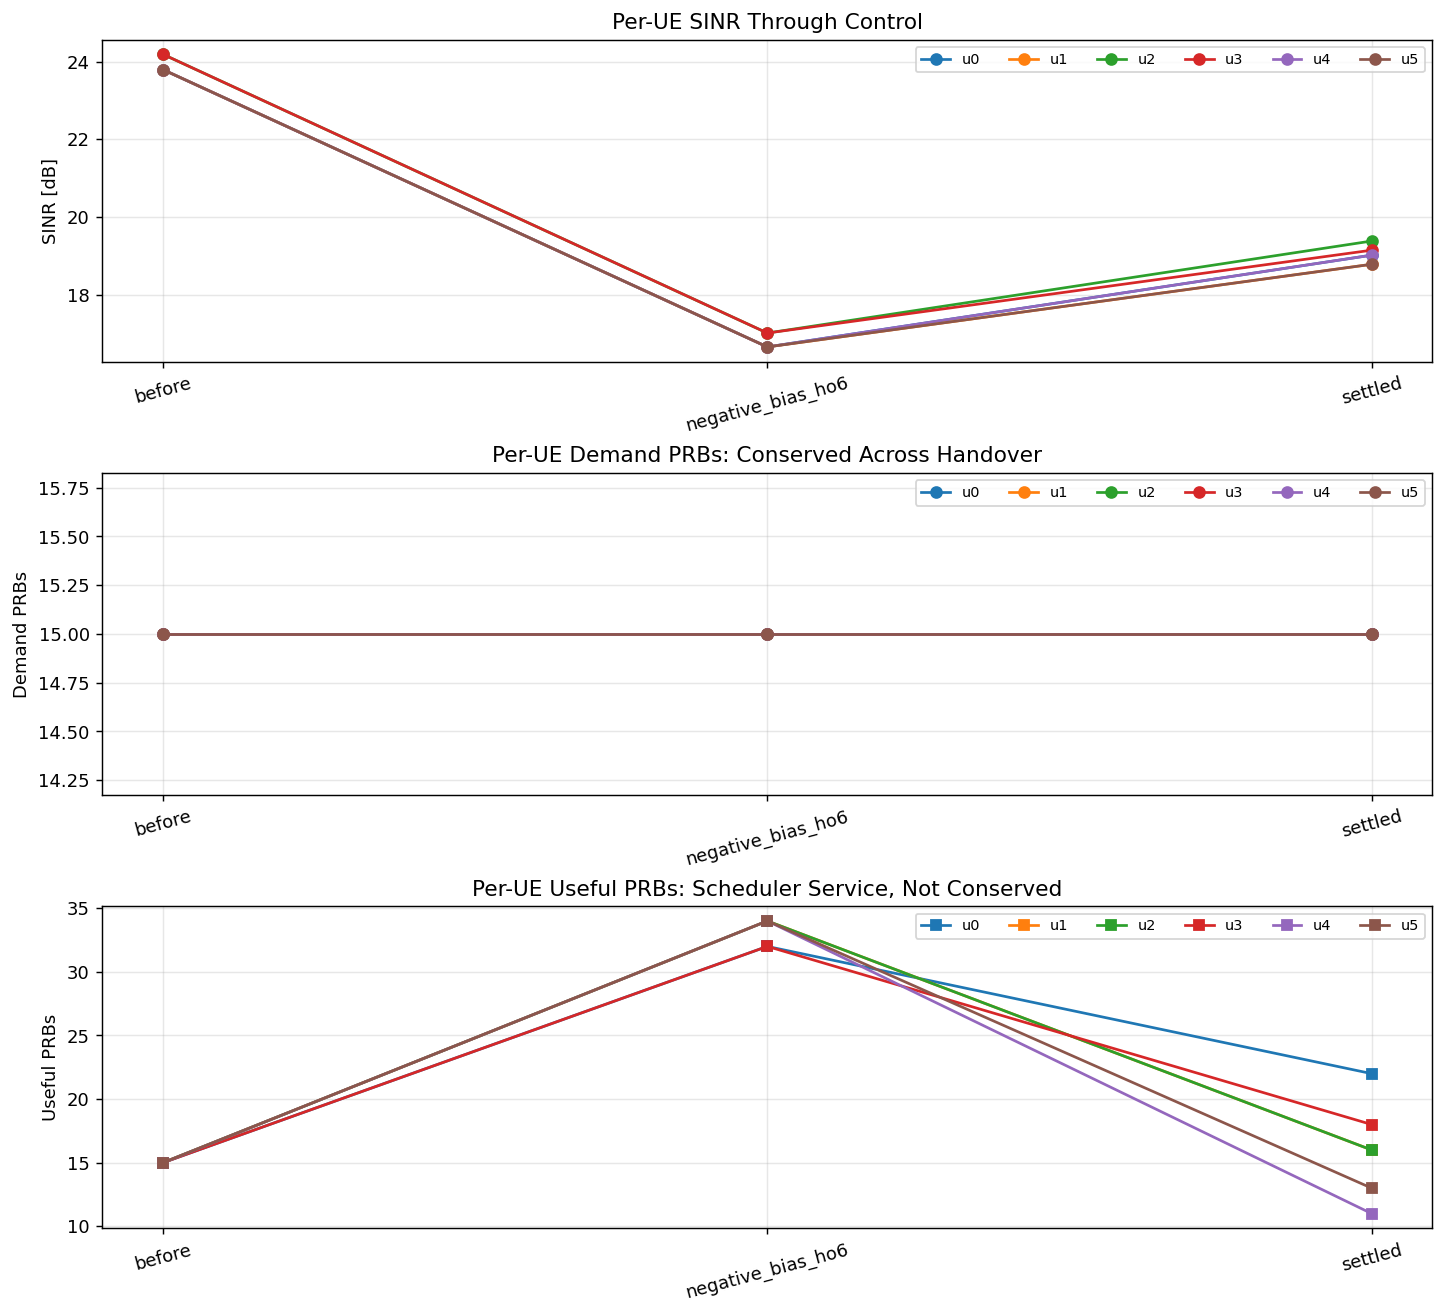

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=False, constrained_layout=True)
tag_order = list(per_ue.sort_values('control_step')['tag'].drop_duplicates())

for ue_id, group in per_ue.groupby('ue_id'):
    group = group.sort_values('control_step')
    axes[0].plot(group['tag'], group['sinr_db'], marker='o', label=f'u{ue_id}')
    axes[1].plot(group['tag'], group['demand_prbs'], marker='o', label=f'u{ue_id}')
    axes[2].plot(group['tag'], group['useful_prbs'], marker='s', label=f'u{ue_id}')

axes[0].set_ylabel('SINR [dB]')
axes[0].set_title('Per-UE SINR Through Control')
axes[0].grid(True, alpha=0.3)
axes[0].legend(ncol=6, fontsize=8)

axes[1].set_ylabel('Demand PRBs')
axes[1].set_title('Per-UE Demand PRBs: Conserved Across Handover')
axes[1].grid(True, alpha=0.3)
axes[1].legend(ncol=6, fontsize=8)

axes[2].set_ylabel('Useful PRBs')
axes[2].set_title('Per-UE Useful PRBs: Scheduler Service, Not Conserved')
axes[2].grid(True, alpha=0.3)
axes[2].legend(ncol=6, fontsize=8)
for ax in axes:
    ax.set_xticks(range(len(tag_order)))
    ax.set_xticklabels(tag_order, rotation=15)
plt.show()


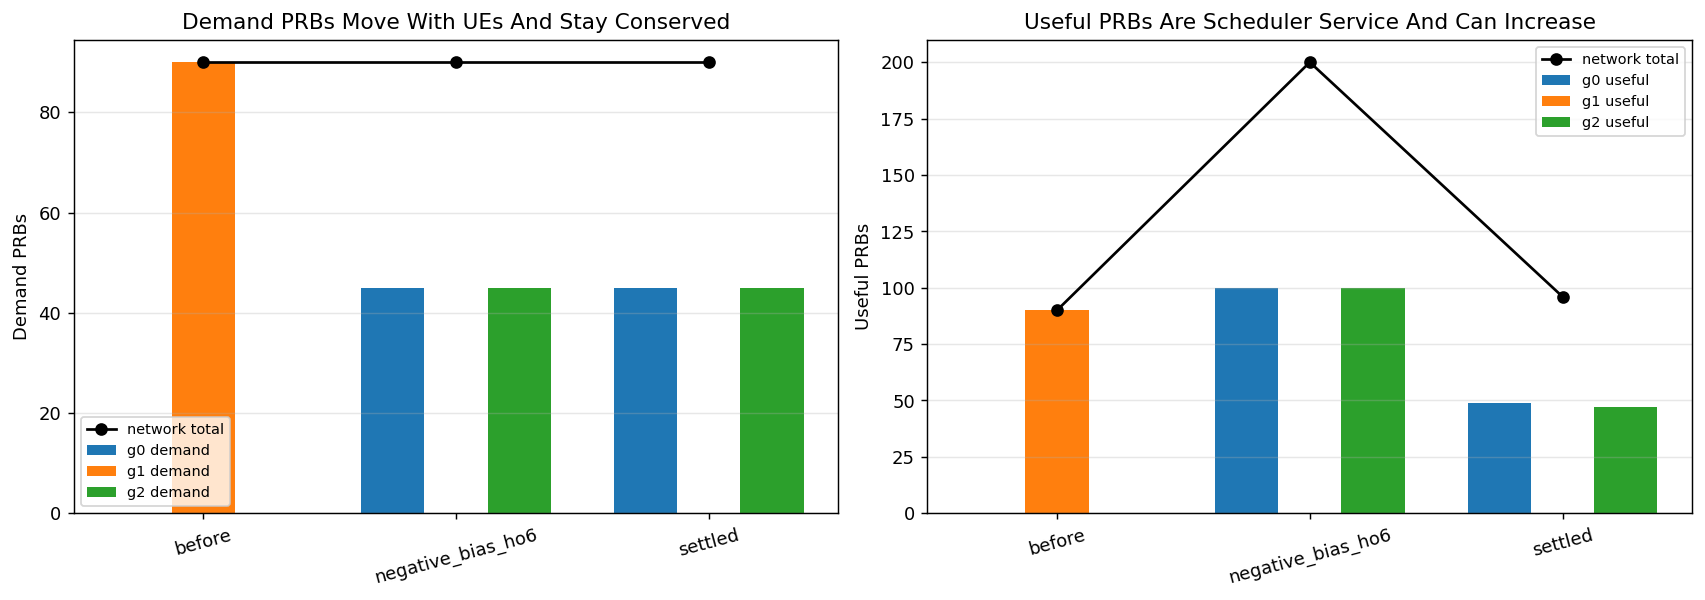

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
x = np.arange(len(tag_order))
width = 0.25
gnb_ids = sorted(per_ue_summary['serving_gnb'].unique())

for i, gnb_id in enumerate(gnb_ids):
    group = (
        per_ue_summary[per_ue_summary['serving_gnb'] == gnb_id]
        .set_index('tag')
        .reindex(tag_order)
        .fillna(0)
    )
    axes[0].bar(x + (i - 1) * width, group['total_demand_prbs'], width=width, label=f'g{int(gnb_id)} demand')
    axes[1].bar(x + (i - 1) * width, group['total_useful_prbs'], width=width, label=f'g{int(gnb_id)} useful')

axes[0].plot(x, network_prb_summary.set_index('tag').reindex(tag_order)['network_demand_prbs'], color='black', marker='o', label='network total')
axes[0].set_title('Demand PRBs Move With UEs And Stay Conserved')
axes[0].set_ylabel('Demand PRBs')
axes[0].set_xticks(x)
axes[0].set_xticklabels(tag_order, rotation=15)
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].plot(x, network_prb_summary.set_index('tag').reindex(tag_order)['network_useful_prbs'], color='black', marker='o', label='network total')
axes[1].set_title('Useful PRBs Are Scheduler Service And Can Increase')
axes[1].set_ylabel('Useful PRBs')
axes[1].set_xticks(x)
axes[1].set_xticklabels(tag_order, rotation=15)
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].legend(fontsize=8)
plt.show()
